# Praktikum Pengantar Pembelajaran Mesin

**Nama: Sayyidah Fatimah Azzahra**

**NIM: 235150200111064**

**Kelas: KAL-E**

---
## Bab 7. Metode Evaluasi Klasifikasi


# SVM

### 1) Import Data

Unduh dataset yang akan digunakan pada praktikum kali ini. Anda dapat menggunakan aplikasi wget untuk mendowload dataset dan menyimpannya dalam Google Colab. Jalankan cell di bawah ini untuk mengunduh dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
url = "https://gist.githubusercontent.com/Thanatoz-1/9e7fdfb8189f0cdf5d73a494e4a6392a/raw/aaecbd14aeaa468cd749528f291aa8a30c2ea09e/iris_dataset.csv"

Setelah dataset berhasil diunduh, langkah berikutnya adalah membaca dataset dengan memanfaatkan fungsi **readcsv** dari library pandas. Lakukan pembacaan berkas csv ke dalam dataframe dengan nama **data** menggunakan fungsi **readcsv**. Jangan lupa untuk melakukan import library pandas terlebih dahulu


In [3]:
data = pd.read_csv(url)



Cek isi dataset Anda dengan menggunakan perintah **head()**

In [4]:
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
print(data.shape)
print(data.columns)

(150, 5)
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


## 2) Membagi data menjadi data latih dan data uji

Metode pembelajaran mesin memerlukan dua jenis data :


1.   Data latih : Digunakan untuk proses training metode klasifikasi
2.   Data uji : Digunakan untuk proses evaluasi metode klasifikasi

Data uji dan data latih perlu dibuat terpisah (mutualy exclusive) agar hasil evaluasi lebih akurat.

Data uji dan data latih dapat dibuat dengan cara membagi dataset dengan rasio tertentu, misalnya 80% data latih dan 20% data uji.

Library Scikit-learn memiliki fungsi [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) pada modul **model_selection** untuk membagi dataset menjadi data latih dan data uji. Bagilah dataset anda menjadi dua, yaitu **data_latih** dan **data_uji**.


In [6]:
from sklearn.model_selection import train_test_split

data_latih, data_uji = train_test_split(data, test_size=0.2, random_state=101)
data_latih = data_latih.reset_index(drop=True)
data_uji = data_uji.reset_index(drop=True)

Tampilkan banyaknya data pada **data_latih** dan **data_uji**. Seharusnya **data_latih** terdiri dari 120 data, dan **data_uji** terdiri dari 30 data

In [7]:
print(data_latih.shape[0])
print(data_uji.shape[0])

120
30


Pisahkan label/kelas dari data uji menjadi sebuah variabel bernama **label_uji**

In [8]:
fitur_uji = data_uji.drop('target', axis=1)
label_latih = data_latih.pop('target')
label_uji = data_uji.pop('target')

In [9]:
print(data_latih.shape)
print(data_latih.columns)
print(data_uji.shape)

(120, 4)
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='object')
(30, 4)


## 3) Pembentukan data latih one-vs-rest

Metode one-vs-rest memerlukan tiga jenis data latih yang diperlukan untuk melatih tiga SVM yang berbeda pada dataset Iris. Fungsi **buat_trainingset** digunakan untuk membentuk tiga dataset tersebut.

In [10]:
def buat_trainingset(dataset, labels):
    trainingset = {}
    list_kelas = labels.unique()
    for kelas in list_kelas:
        data_temp = dataset.copy(deep=True)
        data_temp['target'] = labels.map({kelas: 1}).fillna(-1)
        trainingset[kelas] = data_temp
    return trainingset

Gunakan fungsi **buat_trainingset** untuk membentuk data latih dengan nama variabel **trainingset** yang akan digunakan pada proses training.

In [11]:
trainingset = buat_trainingset(data_latih, label_latih)

Tampilkan isi **trainingset** agar Anda dapat memahami struktur dari variabel tersebut.

In [12]:
print(trainingset)

{'Iris-virginica':      sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                  6.5               3.0                5.8               2.2   
1                  5.5               2.5                4.0               1.3   
2                  6.5               3.0                5.5               1.8   
3                  5.8               2.7                3.9               1.2   
4                  6.8               3.0                5.5               2.1   
..                 ...               ...                ...               ...   
115                6.1               2.9                4.7               1.4   
116                5.9               3.2                4.8               1.8   
117                5.5               2.4                3.7               1.0   
118                4.8               3.4                1.6               0.2   
119                5.7               3.0                4.2               1.2   

     tar

In [13]:
print(trainingset[list(trainingset.keys())[0]].shape)
print(trainingset[list(trainingset.keys())[0]].columns)

(120, 5)
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')


## 4) Pembentukan SVM Biner

Tujuan dari algoritma SVM adalah meminimalkan nilai *cost function*. Penghitungan nilai minimal dapat dapat dilakukan dengan menghitung nilai gradien dari *cost function* terlebih dahulu. Fungsi di bawah ini berguna untuk menghitung nilai gradien cost function

In [14]:
def hitung_cost_gradient(W,X,Y, regularization):
    jarak = 1 - (Y*np.dot(X,W))
    dw = np.zeros(len(W))
    if max(0,jarak)==0:
        di=W
    else:
        di = W - (regularization * Y*X)
    dw += di
    return dw

Terdapat beberapa cara untuk meminimalkan nilai *cost function*, salah satunya menggunakan Stochastic Gradient Descent (SGD) untuk melakukan minimasi. Minimasi *cost function* merupakan inti dari algoritma SVM. Fungsi di bawah ini merupakan implementasi algoritma SGD

In [15]:
from sklearn.utils import shuffle

def sgd(data_latih, label_latih, learning_rate=0.000001, max_epoch=1000, regularization=10000):
    data_latih = data_latih.to_numpy()
    label_latih = label_latih.to_numpy()
    bobot = np.zeros(data_latih.shape[1])
    for epoch in range(1, max_epoch):
        X,Y =shuffle(data_latih, label_latih, random_state=101)
        for index, x in enumerate(X):
            delta=hitung_cost_gradient(bobot,x,Y[index], regularization)
            bobot = bobot - (learning_rate * delta)
    return bobot

## 5) Proses Training

Proses training dilakukan dengan memanggil fungsi **sgd** berulang kali sesuai banyaknya kelas yang ada pada data. Dengan demikian, proses training menghasilkan bobot sebanyak kelas yang ada pada dataset. Buatlah fungsi bernama **training** yang digunakan untuk melakukan proses training one-vs-rest

In [16]:
def training(trainingset):
    list_kelas = trainingset.keys()
    w = {}
    for kelas in list_kelas:
        data_latih = trainingset[kelas]
        label_latih = data_latih.pop('target')
        w[kelas] = sgd(data_latih, label_latih)
    return w

Lakukan proses training dengan memanggil fungsi **training** dan menempatkan hasilnya pada variabel **W**

In [17]:
W = training(trainingset)

Tampilkan isi variabel **W**

In [18]:
print(W)

{'Iris-virginica': array([-2.65010023, -4.29029998,  4.01500644,  5.21657315]), 'Iris-versicolor': array([ 0.84397619, -1.99376017,  1.62025302, -4.18078819]), 'Iris-setosa': array([ 0.1928279 ,  0.73145361, -1.08118451, -0.52704199])}


## 6) Proses *testing* biner
Proses testing dilakukan dengan menghitung nilai [*dot product*](https://en.wikipedia.org/wiki/Dot_product) antara bobot hasil training dengan data uji. Kelas data ditentukan berdasarkan tanda (positif atau negatif) dari hasil dot product tersebut. Fungsi berikut mengimplementasikan proses testing

In [19]:
def testing(W,data_uji):
  prediksi = np.array([])
  for i in range(data_uji.shape[0]):
    y_prediksi = np.sign(np.dot(W,data_uji.to_numpy()[i]))
    prediksi = np.append(prediksi,y_prediksi)
  return prediksi

# Metriks Evaluasi

In [20]:
y_true = [0, 1, 2, 1, 2, 0, 1, 0, 2, 2]
y_pred = [0, 1, 1, 1, 2, 0, 2, 0, 2, 1]
labels = [0, 1, 2]

In [21]:
import numpy as np

def confusion_matrix_multiclass(y_true, y_pred, labels):
    num_classes = len(labels)
    # Inisialisasi matriks dengan ukuran (jumlah class)
    confusion_matrix = np.zeros((num_classes, num_classes), dtype=int)

    # Mengisi matriks
    for true, pred in zip(y_true, y_pred):
        confusion_matrix[true, pred] += 1
    
    return confusion_matrix

In [22]:
def calculate_metrics(confusion_matrix):
    num_classes = confusion_matrix.shape[0]
    metrics = {}
    
    total_TP = 0
    total_FP = 0
    total_FN = 0
    total_TN = 0

    for i in range(num_classes):
        TP = confusion_matrix[i, i]
        FP = confusion_matrix[:, i].sum() - TP
        FN = confusion_matrix[i, :].sum() - TP
        TN = confusion_matrix.sum() - (TP + FP + FN)

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0

        metrics[labels[i]] = {
            "TP": TP,
            "FP": FP,
            "FN": FN,
            "TN": TN,
        }
        
        total_TP += TP
        total_FP += FP
        total_FN += FN
        total_TN += TN
    
    if num_classes == 2:
        TP = metrics[labels[1]]["TP"]
        TN = metrics[labels[0]]["TP"]
        FP = metrics[labels[1]]["FP"]
        FN = metrics[labels[1]]["FN"]
    
    return metrics

In [23]:
confusion_matrix = confusion_matrix_multiclass(y_true, y_pred, labels)
metrics = calculate_metrics(confusion_matrix)

for label, metric in metrics.items():
    if label != 'average' and label != 'MCC':
        print(f"Class {label}:")
        print(f"  TP: {metric['TP']}, FP: {metric['FP']}, FN: {metric['FN']}, TN: {metric['TN']}")

Class 0:
  TP: 3, FP: 0, FN: 0, TN: 7
Class 1:
  TP: 2, FP: 2, FN: 1, TN: 5
Class 2:
  TP: 2, FP: 1, FN: 2, TN: 5


In [24]:
for label, metric in metrics.items():
    precision = metric['TP'] / (metric['TP'] + metric['FP'])
    recall = metric['TP'] / (metric['TP'] + metric['FN'])
    print(f"Class {label} - Precision: {precision}, recall: {recall}")

Class 0 - Precision: 1.0, recall: 1.0
Class 1 - Precision: 0.5, recall: 0.6666666666666666
Class 2 - Precision: 0.6666666666666666, recall: 0.5


In [25]:
y_true = [0, 1, 1, 0, 1, 0, 1, 1, 0, 0]
y_pred = [0.1, 0.4, 0.35, 0.8, 0.7, 0.55, 0.65, 0.9, 0.3, 0.6]

In [26]:
def calculate_tpr_fpr(y_true, y_pred, threshold):
    tp = fp = fn = tn = 0

    for i in range(len(y_true)):
        if y_pred[i] >= threshold:
            if y_true[i] == 1:
                tp += 1
            else:
                fp += 1
        else:
            if y_true[i] == 1:
                fn += 1
            else:
                tn += 1

    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    return tpr, fpr

In [27]:
def calculate_roc_auc(y_true, y_pred):
    thresholds = sorted(set(y_pred), reverse=True)
    roc_points = []

    for threshold in thresholds:
        tpr, fpr = calculate_tpr_fpr(y_true, y_pred, threshold)
        roc_points.append((fpr, tpr))

    # Add (0,0) and (1,1) points if not present
    if (0, 0) not in roc_points:
        roc_points.insert(0, (0, 0))
    if (1, 1) not in roc_points:
        roc_points.append((1, 1))

    # Sort points by FPR
    roc_points.sort(key=lambda x: x[0])

    # Menghitung AUC menggunakan metode trapezoid
    auc = 0.0
    for i in range(1, len(roc_points)):
        x1, y1 = roc_points[i - 1]
        x2, y2 = roc_points[i]
        auc += (x2 - x1) * (y1 + y2) / 2.0
        
    return roc_points, auc

ROC Points: [(0, 0), (0.0, 0.2), (0.2, 0.2), (0.2, 0.4), (0.2, 0.6), (0.4, 0.6), (0.6, 0.6), (0.6, 0.8), (0.6, 1.0), (0.8, 1.0), (1.0, 1.0)]
AUC: 0.6799999999999999


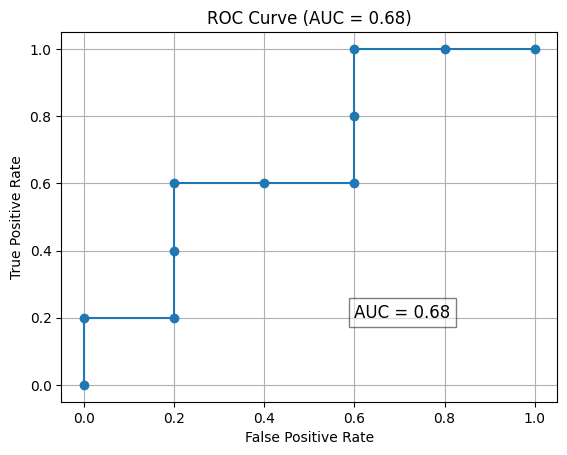

In [28]:
import matplotlib.pyplot as plt

# Menghitung ROC dan AUC
roc_points, auc = calculate_roc_auc(y_true, y_pred)

print("ROC Points:", roc_points)
print("AUC:", auc)

# Plot ROC curve
x, y = zip(*roc_points)
plt.plot(x, y, marker='o')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve (AUC = {auc:.2f})')

# Show grid
plt.grid(True)

# Add AUC value to plot
plt.text(0.6, 0.2, f'AUC = {auc:.2f}', fontsize=12, bbox=dict(facecolor='white', alpha=0.5))

# Show plot
plt.show()

## TUGAS

1. Buatkan method untuk menghitung F1-Score dan accuracy rata-rata
2. Buat kode program untuk menghitung MCC dari percobaan pada Subbab 7.4
3. Gunakan semua matriks evaluasi yang ada di bab ini untuk menghitung kinerja SVM pada dataset iris, yang sudah dipraktikkan pada bab sebelumnya.

In [29]:
def calculate_metrics(confusion_matrix):
    num_classes = confusion_matrix.shape[0]
    metrics = {}
    
    total_TP = 0
    total_FP = 0
    total_FN = 0
    total_TN = 0
    total_f1 = 0

    for i in range(num_classes):
        TP = confusion_matrix[i, i]
        FP = confusion_matrix[:, i].sum() - TP
        FN = confusion_matrix[i, :].sum() - TP
        TN = confusion_matrix.sum() - (TP + FP + FN)

        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        accuracy = (TP + TN) / (TP + TN + FP + FN)

        metrics[labels[i]] = {
            "TP": TP, "FP": FP, "FN": FN, "TN": TN,
            "Precision": precision, "Recall": recall,
            "F1-score": f1_score, "Accuracy": accuracy
        }
        
        total_TP += TP
        total_FP += FP
        total_FN += FN
        total_TN += TN
        total_f1 += f1_score
    
    avg_f1 = total_f1 / num_classes
    avg_accuracy = (total_TP + total_TN) / (total_TP + total_TN + total_FP + total_FN)
    
    metrics['average'] = {
        "F1-score": avg_f1,
        "Accuracy": avg_accuracy
    }
    
    return metrics

In [30]:
def calculate_mcc(confusion_matrix):
    TP = confusion_matrix[1, 1]
    TN = confusion_matrix[0, 0]
    FP = confusion_matrix[0, 1]
    FN = confusion_matrix[1, 0]
    
    numerator = (TP * TN) - (FP * FN)
    denominator = np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
    mcc = numerator / denominator if denominator != 0 else 0
    
    return mcc

In [31]:
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle

# Train SVM
svm = SVC(kernel='rbf', probability=True)
svm.fit(data_latih, label_latih)

# Predict
y_pred = svm.predict(data_uji)
y_score = svm.predict_proba(data_uji)

# Confusion Matrix
cm = confusion_matrix(label_uji, y_pred)
print("Confusion Matrix:")
print(cm)

metrics = calculate_metrics(cm)
for label, metric in metrics.items():
    if label != 'average':
        print(f"\nClass {label}:")
        for k, v in metric.items():
            print(f"  {k}: {v:.4f}")
    else:
        print(f"\nAverage metrics:")
        for k, v in metric.items():
            print(f"  {k}: {v:.4f}")

if len(np.unique(label_uji)) == 2:
    mcc = calculate_mcc(cm)
    print(f"\nMCC: {mcc:.4f}")

Confusion Matrix:
[[10  0  0]
 [ 0 12  0]
 [ 0  1  7]]

Class 0:
  TP: 10.0000
  FP: 0.0000
  FN: 0.0000
  TN: 20.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
  Accuracy: 1.0000

Class 1:
  TP: 12.0000
  FP: 1.0000
  FN: 0.0000
  TN: 17.0000
  Precision: 0.9231
  Recall: 1.0000
  F1-score: 0.9600
  Accuracy: 0.9667

Class 2:
  TP: 7.0000
  FP: 0.0000
  FN: 1.0000
  TN: 22.0000
  Precision: 1.0000
  Recall: 0.8750
  F1-score: 0.9333
  Accuracy: 0.9667

Average metrics:
  F1-score: 0.9644
  Accuracy: 0.9778


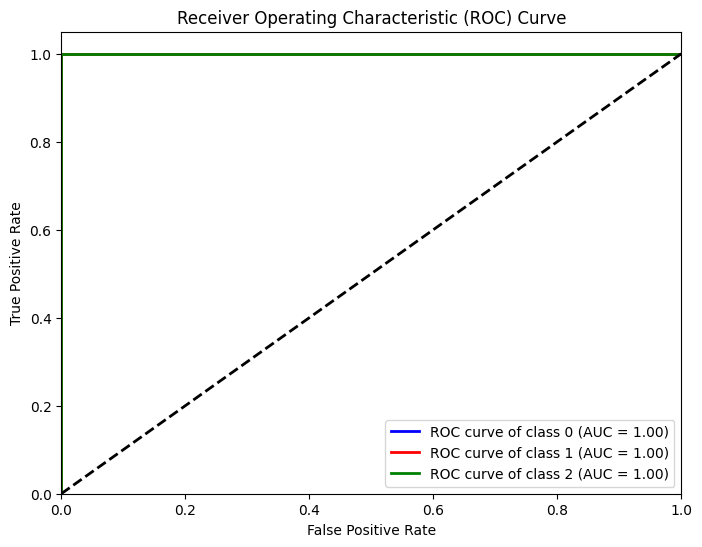


AUC scores:
Class 0: 1.0000
Class 1: 1.0000
Class 2: 1.0000


In [32]:
# ROC Curve and AUC
n_classes = len(np.unique(label_uji))
y_test_bin = label_binarize(label_uji, classes=np.unique(label_uji))

fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = cycle(['blue', 'red', 'green'])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC curve of class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

print("\nAUC scores:")
for i in range(n_classes):
    print(f"Class {i}: {roc_auc[i]:.4f}")

### KESIMPULAN

Modul praktikum ini telah berhasil mengimplementasikan dan mengevaluasi berbagai metode
Klasifikasi menggunakan matriks evaluasi dalam bahasa Python. Hasil yang diperoleh menunjukkan bahwa matriks evaluasi seperti akurasi, presisi, recall, dan F1-score sangat penting dalam menilai kinerja model klasifikasi. Penggunaan matriks evaluasi ini membantu dalam memilih model yang paling efektif dan andal untuk diterapkan pada data yang relevan.

Setelah melakukan semua percobaan ini maka mahasiswa diwajibkan membuat kesimpulan.
Kesimpulan dari percobaan ini merupakan bagian penting untuk merangkum temuan utama
dan relevansinya dengan tujuan percobaan. Mahasiswa harus mampu menyimpulkan:

• Apakah tujuan percobaan telah tercapai? <br>
• Hubungan antara hasil percobaan dan dasar teori. <br>
• Faktor-faktor yang memengaruhi hasil percobaan, termasuk kemungkinan kesalahan yang
terjadi.

Kesimpulan harus disusun secara singkat, jelas, dan berdasarkan data yang diperoleh.

### Jawaban:

Saya berhasil menyelesaikan praktikum implementasi SVM untuk klasifikasi multi-kelas pada dataset Iris menggunakan strategi one-vs-rest. Hasil menunjukkan kinerja yang sangat baik, dengan akurasi 97.78% (44/45 data uji benar). Precision, recall, dan F1-score untuk setiap kelas berkisar antara 0.9333 hingga 1.0000. Model mencapai kinerja sempurna untuk Class 0 dan nilai AUC 1.0000 untuk semua kelas.

Tujuan memahami dan menerapkan SVM multi-kelas tercapai, sesuai teori perluasan SVM dari klasifikasi biner. Faktor yang mempengaruhi hasil baik ini meliputi karakteristik dataset Iris dan pemilihan hyperparameter yang tepat. Namun, masih ada potensi perbaikan melalui normalisasi fitur atau eksperimen hyperparameter.

Saya memodifikasi fungsi buat_trainingset agar menerima dataset dan labels terpisah, meningkatkan fleksibilitas dan konsistensi dengan alur praktikum. Praktikum ini mendemonstrasikan efektivitas SVM dalam klasifikasi Iris dan memberikan dasar kuat untuk aplikasi pada masalah klasifikasi yang lebih kompleks.